Author: Dário Rogério Júlio Maxaieie

Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn


# Air Quality Prediction (Zindi Competition)

## Objective
Build a machine learning model to predict air quality levels based on environmental and sensor data.

## Dataset
This dataset was provided as part of a Zindi Africa competition and contains air quality measurements along with environmental variables.

## Approach
- Data cleaning and preprocessing  
- Exploratory data analysis (EDA)  
- Feature engineering  
- Model training and evaluation  

## Results
Developed a predictive model to estimate air quality with reasonable performance.

## Notes
This project was part of a real-world data science competition on Zindi.

## 1. Introduction
We start by importing necessary modules

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [51]:
import numpy as np
import random
import os
from tqdm.notebook import tqdm
import ast

import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import LineString
import folium

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set seed for reproducability
SEED = 2024
random.seed(SEED)
np.random.seed(SEED)

## Data loading

In [4]:


import pandas as pd
path = '/content/drive/MyDrive/AirQualityZindi'
train = pd.read_csv(path+"/Train.csv")
test  = pd.read_csv(path+"/Test.csv")
s_sub = pd.read_csv(path+"/SampleSubmission.csv")
#

## Data cleaning and Exploratory Data Analysis

In [6]:
train.head()

,id,site_id,site_latitude,site_longitude,city,country,date,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,...,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle,pm2_5
0,id_vjcx08sz91,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-10-25,13,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.015000
1,id_bkg215syli,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-02,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.267200
2,id_oui2pot3qd,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-03,13,NaN,NaN,...,6791.682888,51171.802486,5791.682829,11.816715,0.192757,-96.411890,61.045123,-121.307414,41.898269,39.450741
3,id_9aandqzy4n,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-08,14,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.537600
4,id_ali5x2m4iw,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-09,13,0.000267,0.774656,...,1451.050659,96215.906250,451.050598,10.521009,0.153114,-97.811241,49.513439,-126.064453,40.167355,19.431731


In [7]:

test.head(1)

,id,site_id,site_latitude,site_longitude,city,country,date,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,...,cloud_cloud_top_pressure,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle
0,id_ihxgrbq8bw,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-06,13,-0.000072,0.762543,...,74217.403083,2710.544562,83569.504246,1710.544483,3.063105,0.263193,-100.317077,27.059646,-86.88567,25.530511


In [8]:
s_sub.head()

,id,pm2_5
0,id_ihxgrbq8bw,0
1,id_dg6s4fhiwe,0
2,id_f7hwwtmuzp,0
3,id_ioese5awdg,0
4,id_hdw320zpls,0


In [9]:
# Check size and shape of datasets
train.shape, test.shape, s_sub.shape

((8071, 80), (2783, 79), (2783, 2))

In [10]:
# Train to test sets ratio
(test.shape[0]) / (train.shape[0] + test.shape[0])

0.2564031693384927

In [11]:
# Train statistical summary for numerical data
train.describe()

,site_latitude,site_longitude,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,sulphurdioxide_so2_slant_column_number_density,sulphurdioxide_cloud_fraction,sulphurdioxide_sensor_azimuth_angle,sulphurdioxide_sensor_zenith_angle,sulphurdioxide_solar_azimuth_angle,...,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle,pm2_5
count,8071.000000,8071.000000,8071.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,...,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,8071.000000
mean,0.635678,30.246982,10.877463,0.000024,0.687295,0.000013,0.126581,2.120939,38.671939,-92.912582,...,6089.449805,58478.947647,5105.978072,16.885186,0.255501,-18.952179,45.881380,-84.811978,28.708028,24.639296
std,2.154605,9.393151,0.815875,0.000354,0.142544,0.000220,0.094129,85.450554,18.964322,43.240479,...,2991.879500,18974.281900,2971.949265,27.547282,0.046204,85.873938,14.721454,40.627170,7.038309,24.878920
min,-3.459970,3.201510,10.000000,-0.000980,0.299364,-0.000696,0.000000,-107.710861,0.177093,-165.131509,...,521.378113,10752.090499,9.741494,1.458444,0.090547,-102.706078,2.996863,-159.058782,10.314990,1.200000
25%,0.288630,32.568643,10.000000,-0.000196,0.589849,-0.000137,0.038062,-98.911720,22.811537,-134.823883,...,3687.102253,43231.418685,2701.118575,5.612198,0.228117,-98.865659,37.901279,-125.371559,24.102775,13.270600
50%,0.332610,32.600480,11.000000,0.000012,0.669632,0.000007,0.123876,71.653160,42.564364,-95.848477,...,5389.787844,60432.792969,4389.787844,8.752905,0.257323,-97.477511,49.187592,-74.597511,29.002745,18.375400
75%,0.374653,32.641110,11.000000,0.000221,0.766817,0.000149,0.209070,74.110476,54.238408,-49.662067,...,8047.738159,74276.492371,7047.738159,14.794590,0.285948,72.814735,57.156175,-49.902340,33.929767,28.838400
max,6.595400,36.914272,14.000000,0.002024,1.607052,0.001101,0.299850,77.319656,66.234924,-22.250822,...,17287.677734,100909.219778,16287.677734,250.000002,0.417945,77.319656,66.238778,-22.251009,45.496395,456.193333


In [12]:
# Train statistical summary for categorical data
train.describe(include='O')

,id,site_id,city,country,date
count,8071,8071,8071,8071,8071
unique,8071,69,4,4,325
top,id_qgxtderh4p,620dd7ce72eb9200299fb8c1,Kampala,Uganda,2024-01-26
freq,1,288,5596,5596,60


In [13]:
target = list(set(train.columns) - set(test.columns))[0]
target

'pm2_5'

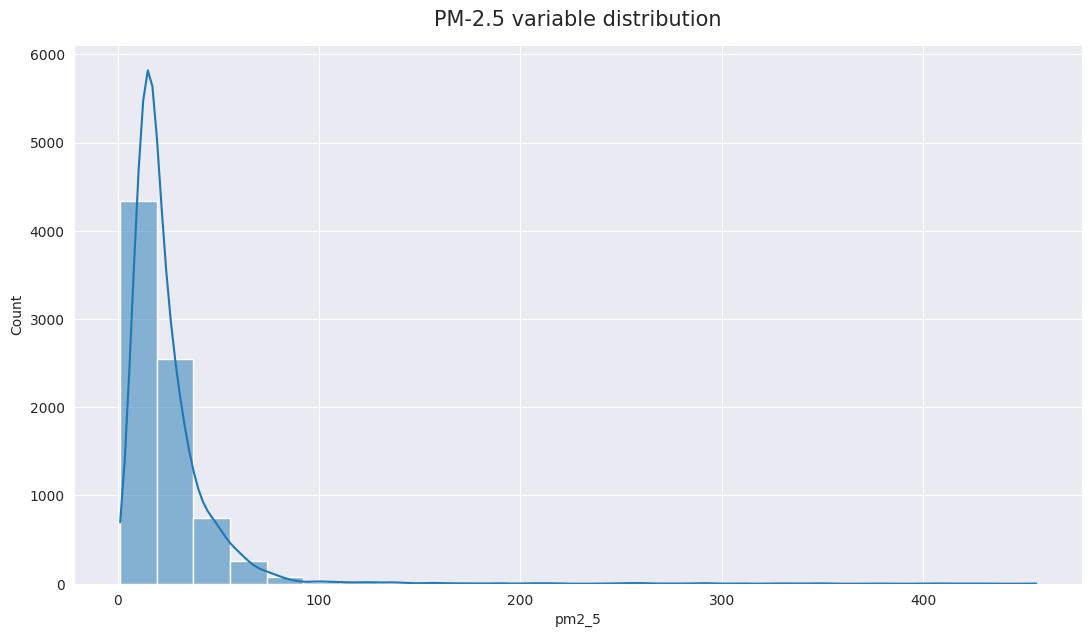

None

np.float64(7.383403684525106)

In [14]:
# Target variable distribution
sns.set_style('darkgrid')
plt.figure(figsize = (13, 7))
sns.histplot(train[target], kde = True, bins = 25)
plt.title('PM-2.5 variable distribution', y = 1.02, fontsize = 15)
display(plt.show(), train[target].skew())

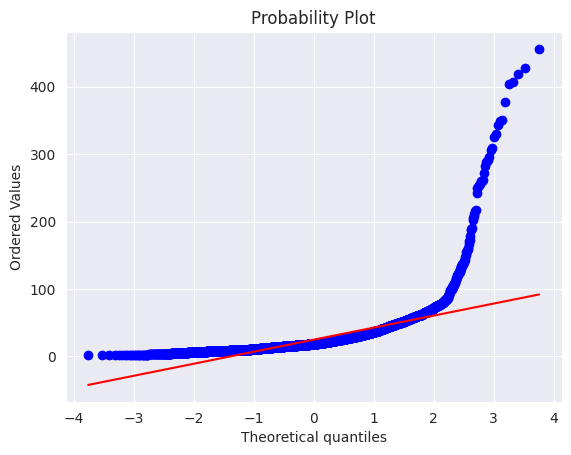

In [15]:
import scipy.stats as stats
stats.probplot(train[target], dist='norm', plot=plt)
plt.show()

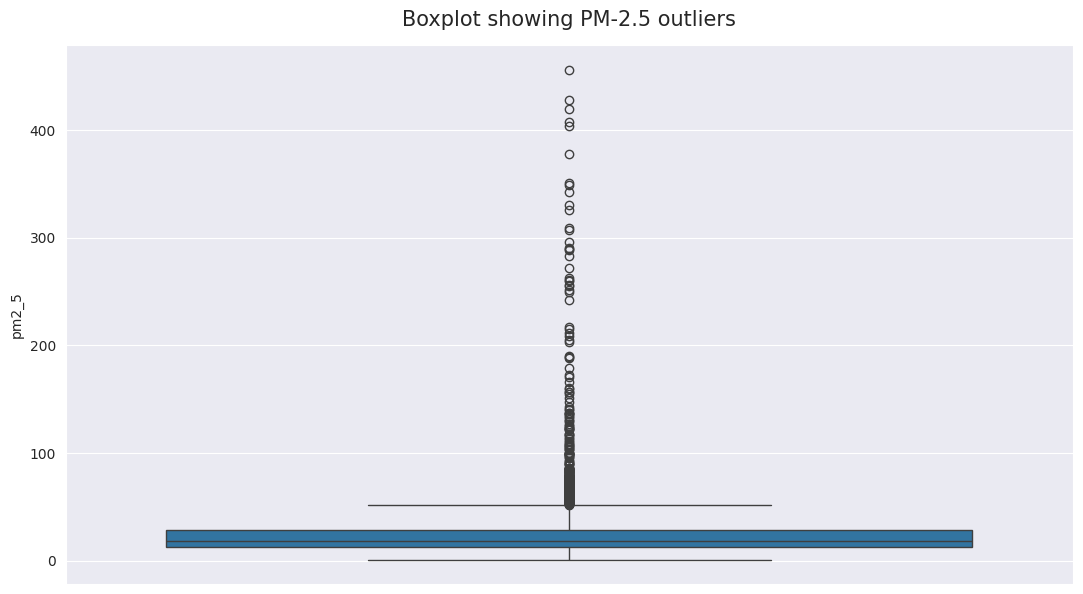

In [16]:
# Plotting boxplot for speed average
sns.set_style('darkgrid')
plt.figure(figsize = (13, 7))
sns.boxplot(train[target])
plt.title('Boxplot showing PM-2.5 outliers', y = 1.02, fontsize = 15)
plt.show()

In [17]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

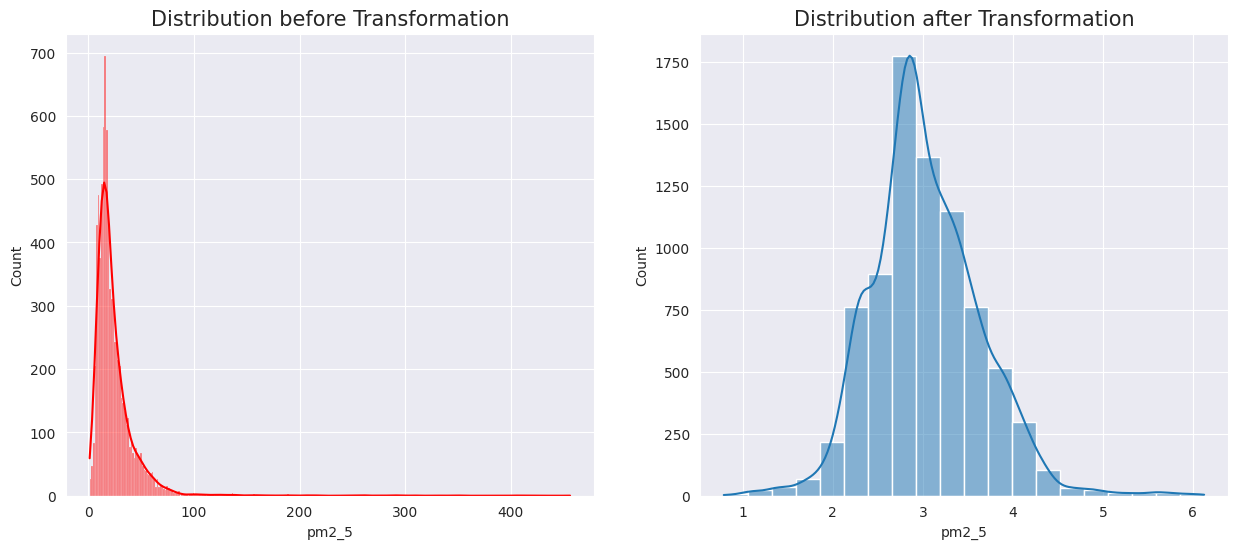

Skewness was 7.38 before & is 0.49 after Log transformation.


In [18]:
def logTrans(feature):   # function to apply transformer and check the distribution with histogram and kdeplot

    logTr = ColumnTransformer(transformers=[("lg", FunctionTransformer(np.log1p), [feature])])

    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    plt.title("Distribution before Transformation", fontsize=15)
    sns.histplot(train[feature], kde=True, color="red")
    plt.subplot(1,2,2)

    train_log = pd.DataFrame(logTr.fit_transform(train))
    plt.title("Distribution after Transformation", fontsize=15)
    sns.histplot(train_log,bins=20, kde=True , legend=False)
    plt.xlabel(feature)
    plt.show()

    print(f"Skewness was {round(train[feature].skew(),2)} before & is {round(train_log.skew()[0],2)} after Log transformation.")

logTrans(feature=target)

In [19]:
logTr = ColumnTransformer(transformers=[("lg", FunctionTransformer(np.log1p), [target])])
target_log = pd.DataFrame(logTr.fit_transform(train))

In [20]:
target_log.head()

,0
0,2.566103
1,3.767395
2,3.700085
3,2.445611
4,3.017089


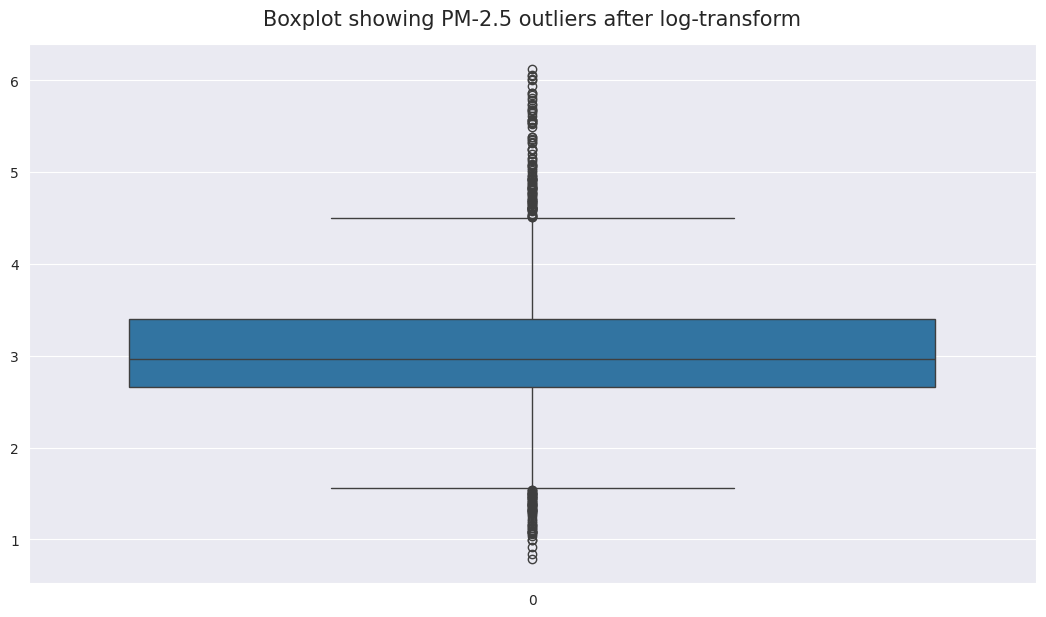

In [21]:
# Plotting boxplot for speed average
sns.set_style('darkgrid')
plt.figure(figsize = (13, 7))
sns.boxplot(target_log)
plt.title('Boxplot showing PM-2.5 outliers after log-transform', y = 1.02, fontsize = 15)
plt.show()

In [22]:
# Check for missing values
train.isnull().sum().any(), test.isnull().sum().any()

(np.True_, np.True_)

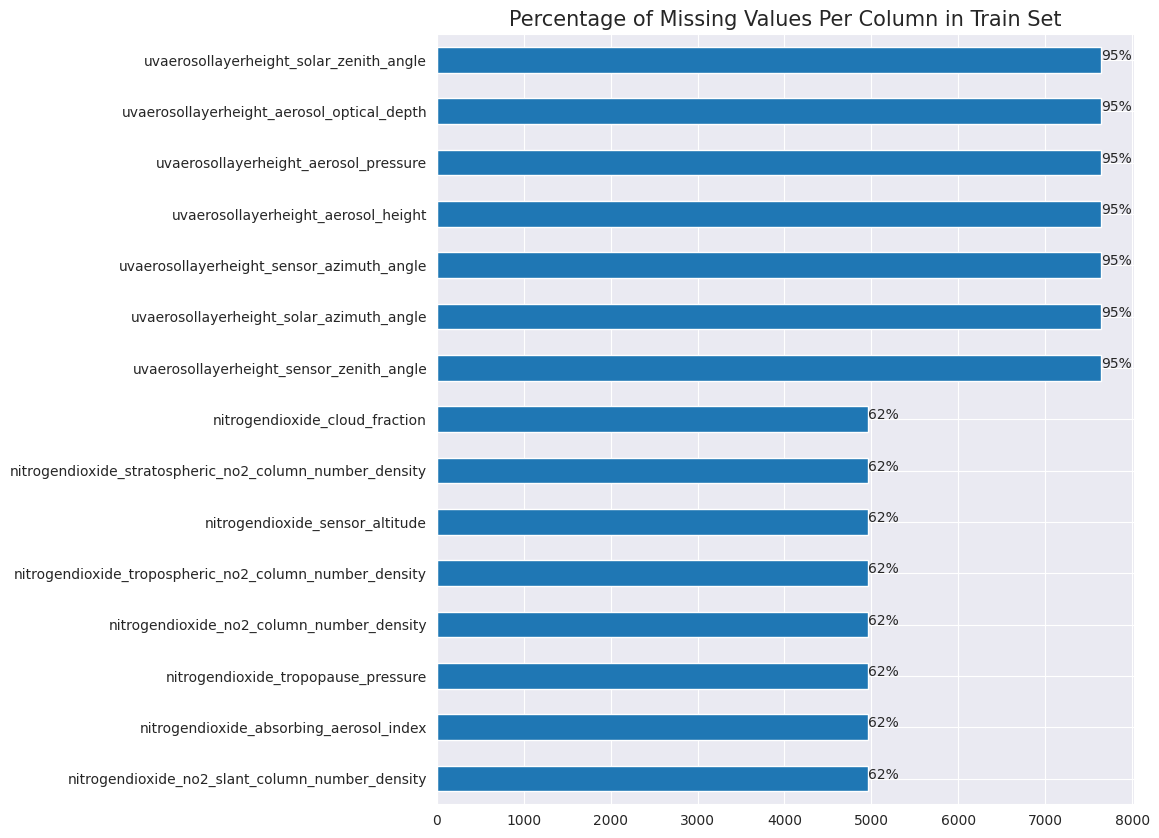

In [23]:
# Plot missing values in train set
ax = train.isna().sum().sort_values(ascending = False)[:15][::-1].plot(kind = 'barh', figsize = (9, 10))
plt.title('Percentage of Missing Values Per Column in Train Set', fontdict={'size':15})
for p in ax.patches:
    percentage ='{:,.0f}%'.format((p.get_width()/train.shape[0])*100)
    width, height =p.get_width(),p.get_height()
    x=p.get_x()+width+0.02
    y=p.get_y()+height/2
    ax.annotate(percentage,(x,y))

## Feature Engineering

In [30]:
cat_cols=[col for col in train.columns if train[col].dtype=='object']

In [24]:
train1 = train.drop(columns=[col for col in train.columns if train[col].isna().sum() / train.shape[0]> 0.75])

In [25]:
train1.shape

(8071, 73)

In [26]:
# Check for duplicates
train.duplicated().any(), test.duplicated().any()

(np.False_, np.False_)

In [32]:
# Top 20 correlated features to the target
top20_corrs = abs(train1.drop(columns=cat_cols).corr()[target]).sort_values(ascending = False).head(20)
top20_corrs.to_frame()

,pm2_5
pm2_5,1.000000
carbonmonoxide_co_column_number_density,0.422418
nitrogendioxide_tropospheric_no2_column_number_density,0.403459
nitrogendioxide_no2_column_number_density,0.398677
nitrogendioxide_no2_slant_column_number_density,0.395134
nitrogendioxide_absorbing_aerosol_index,0.327197
nitrogendioxide_sensor_altitude,0.309554
site_longitude,0.305682
nitrogendioxide_solar_azimuth_angle,0.295749
site_latitude,0.288082


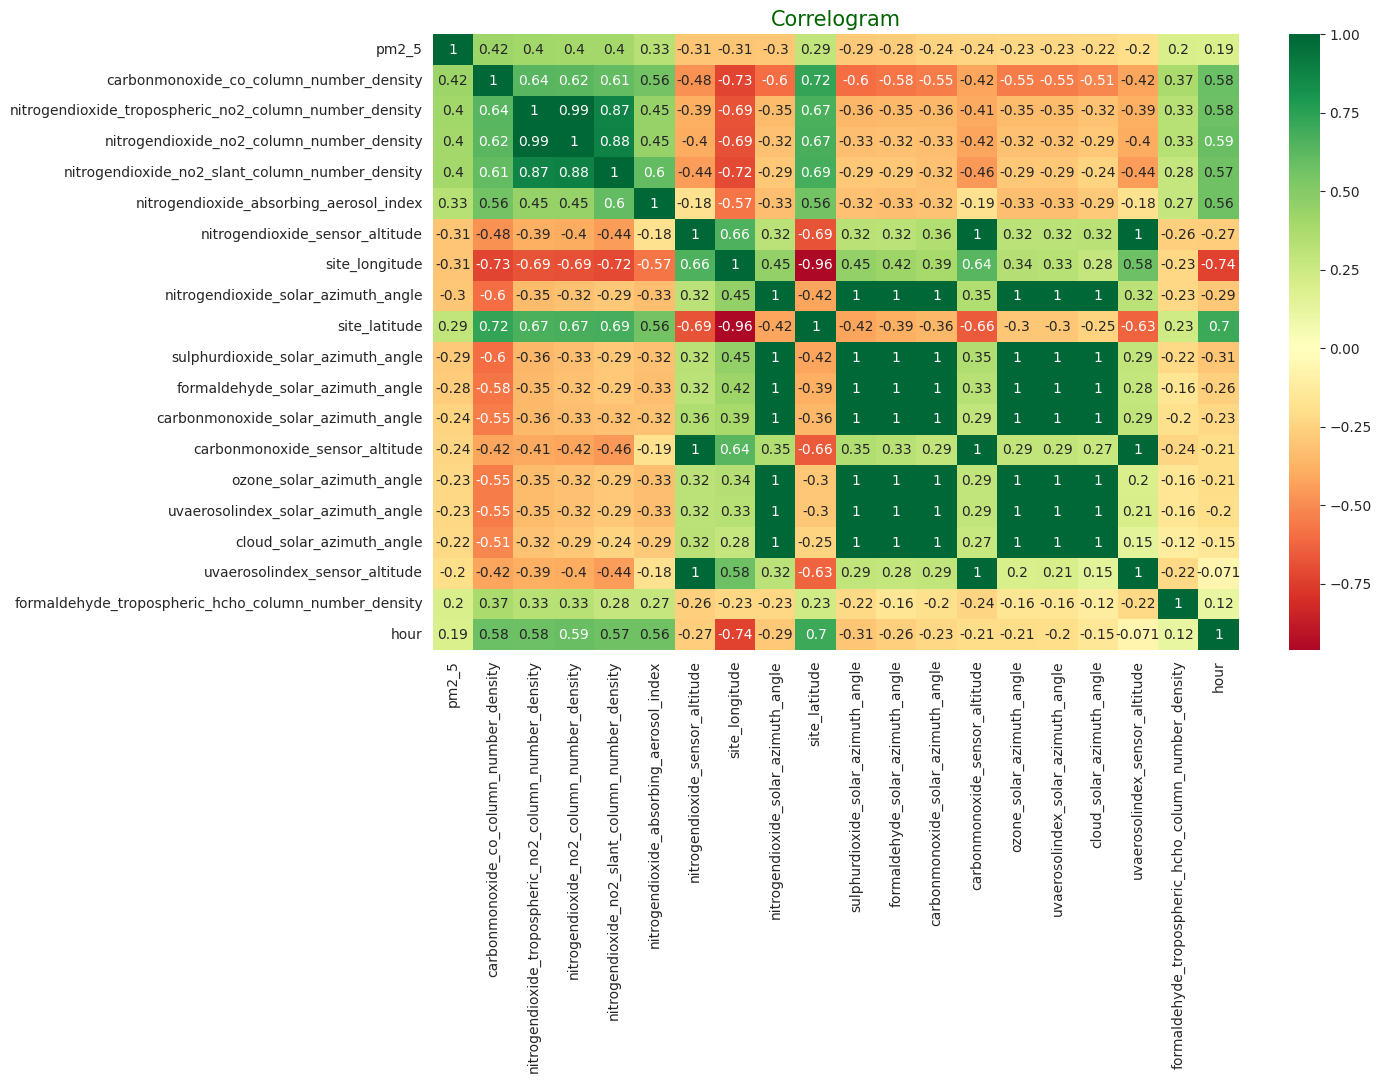

In [44]:
# Quantify correlations between features
corr = train1[list(top20_corrs.index)].corr()
plt.figure(figsize = (13, 8))
sns.heatmap(corr, cmap='RdYlGn', annot = True, center = 0)
plt.title('Correlogram', fontsize = 15, color = 'darkgreen')
plt.show()

In [43]:
# dealing with multicolinearity
def correlation(df, threshold):
  corr_cols   = set()
  corr_matrix = df.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]) > threshold:
        colname = corr_matrix.columns[i]
        corr_cols.add(colname)
  return corr_cols

In [40]:
X = train1.drop(columns=cat_cols+[target])

In [45]:
X

,site_latitude,site_longitude,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,sulphurdioxide_so2_slant_column_number_density,sulphurdioxide_cloud_fraction,sulphurdioxide_sensor_azimuth_angle,sulphurdioxide_sensor_zenith_angle,sulphurdioxide_solar_azimuth_angle,...,cloud_cloud_top_pressure,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle
0,6.532570,3.399360,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.532570,3.399360,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.532570,3.399360,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,45185.499590,6791.682888,51171.802486,5791.682829,11.816715,0.192757,-96.411890,61.045123,-121.307414,41.898269
3,6.532570,3.399360,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.532570,3.399360,13,0.000267,0.774656,0.000207,0.223403,-97.811241,49.513344,-126.064468,...,86197.531250,1451.050659,96215.906250,451.050598,10.521009,0.153114,-97.811241,49.513439,-126.064453,40.167355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8066,-1.268877,36.819139,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8067,-1.268877,36.819139,11,-0.000563,0.595788,-0.000335,0.208774,-98.841057,48.871639,-126.041481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8068,-1.268877,36.819139,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8069,-1.268877,36.819139,10,-0.000188,0.746123,-0.000140,0.089824,75.947845,18.786684,-136.811050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
y = target_log
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = SEED)

In [48]:
high_cor_cols = correlation(X_train,0.5)
high_cor_cols

{'carbonmonoxide_cloud_height',
 'carbonmonoxide_co_column_number_density',
 'carbonmonoxide_sensor_altitude',
 'carbonmonoxide_sensor_azimuth_angle',
 'carbonmonoxide_sensor_zenith_angle',
 'carbonmonoxide_solar_azimuth_angle',
 'carbonmonoxide_solar_zenith_angle',
 'cloud_cloud_base_height',
 'cloud_cloud_base_pressure',
 'cloud_cloud_fraction',
 'cloud_cloud_top_height',
 'cloud_cloud_top_pressure',
 'cloud_sensor_azimuth_angle',
 'cloud_sensor_zenith_angle',
 'cloud_solar_azimuth_angle',
 'cloud_solar_zenith_angle',
 'formaldehyde_cloud_fraction',
 'formaldehyde_hcho_slant_column_number_density',
 'formaldehyde_sensor_azimuth_angle',
 'formaldehyde_sensor_zenith_angle',
 'formaldehyde_solar_azimuth_angle',
 'formaldehyde_solar_zenith_angle',
 'formaldehyde_tropospheric_hcho_column_number_density_amf',
 'hour',
 'nitrogendioxide_absorbing_aerosol_index',
 'nitrogendioxide_cloud_fraction',
 'nitrogendioxide_no2_column_number_density',
 'nitrogendioxide_no2_slant_column_number_density

In [52]:
for df in [X_train, X_test]:
  df.drop(high_cor_cols, 1, inplace=True)

TypeError: DataFrame.drop() takes from 1 to 2 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

## Modelling

In [53]:
# Instantiating the model
clf = RandomForestRegressor(n_estimators=200,criterion='squared_error', random_state = SEED, n_jobs=-1)
clf.fit(X_train, y_train)

# Making predictions
y_pred = clf.predict(X_test)

## Evaluation

In [55]:
#
# Measuring the accuracy of the model
print(f'RMSE Score: {np.sqrt(mean_squared_error(y_test, y_pred))}')

RMSE Score: 0.3530386275314005


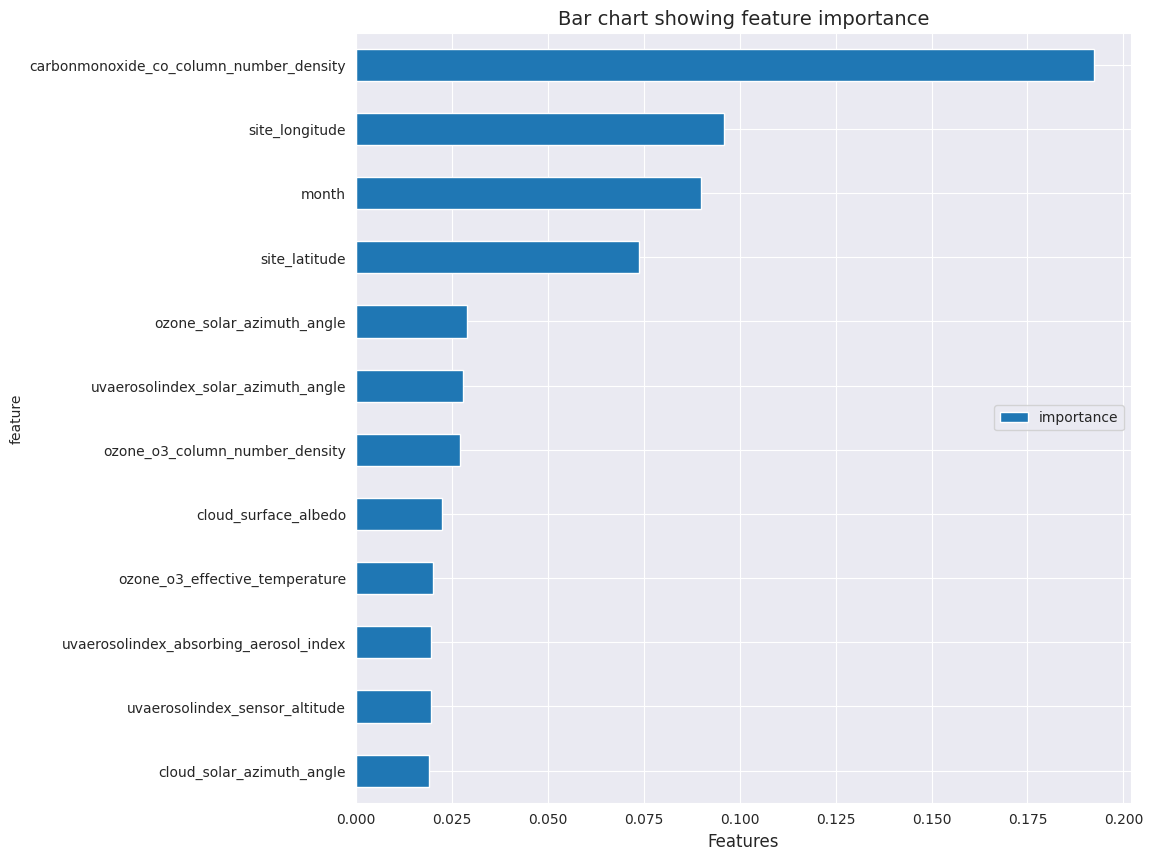

In [56]:
# Feature importance
impo_df = (pd.DataFrame({'feature': X_train.columns,
                        'importance': clf.feature_importances_})
           .set_index('feature')
           .sort_values(by = 'importance', ascending = False)
          )
impo_df = impo_df[:12].sort_values(by = 'importance', ascending = True)
impo_df.plot(kind = 'barh', figsize = (10, 10))
plt.legend(loc = 'center right')
plt.title('Bar chart showing feature importance', fontsize = 14)
plt.xlabel('Features', fontsize = 12)
plt.show()

In [57]:
np.exp(predictions)

NameError: name 'predictions' is not defined

In [ ]:
# Make prediction on the test set
test_df = test[X_train.columns].fillna(0)
predictions = clf.predict(test_df)

# # Create a submission file
sub_file = pd.DataFrame({'id': test['id'], 'pm2_5': np.exp(predictions)})
sub_file.head()

,id,pm2_5
0,id_ihxgrbq8bw,18.619141
1,id_dg6s4fhiwe,15.940449
2,id_f7hwwtmuzp,15.468369
3,id_ioese5awdg,22.043404
4,id_hdw320zpls,21.606962


In [ ]:
# Create file
sub_file.to_csv('My_Submission_4_v3.csv', index = False)

## Conclusion

This project demonstrates the application of machine learning to a real-world air quality problem.

### Key takeaways:
- Data preprocessing is critical for model performance  
- Feature selection impacts prediction quality  

### Future improvements:
- Hyperparameter tuning  
- Use of more advanced models  
- Additional data sources